# Pipeline de Dados — Cibersegurança
## Camadas Bronze e Prata para Machine Learning

Este notebook executa o pipeline completo de engenharia de dados, organizando os dados brutos de incidentes de cibersegurança em duas camadas:

- **Bronze**: dados brutos preservados, com padronização mínima e registro de metadados
- **Prata**: dados limpos, transformados e prontos para uso em modelos preditivos

---

# Pipeline de Dados — Cibersegurança (ML-Ready)
**Arquitetura Medallion: Bronze → Silver → Gold → Modelagem → PySpark**

---

| Informação | Detalhe |
|---|---|
| Dataset | 850 incidentes de cibersegurança |
| Fontes | incidents, financial, market |
| Target | `label_alto_impacto` — perda direta > $10M |
| Modelo | DecisionTreeClassifier |
| Melhor F1 | 95.0% (Árvore 2 — depth=3, entropy) |

---

## 0. Imports e Configuração

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# SEÇÃO 0 — IMPORTS E CONFIGURAÇÃO
# ─────────────────────────────────────────────────────────────────────────────

import sys
import os
import warnings
import json
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore")

# Diretório de trabalho — sobe um nível (notebooks → raiz do projeto)
os.chdir(os.path.abspath(".."))

# Adiciona src ao path para importar bronze, silver, gold, validation
sys.path.insert(0, os.path.abspath("src"))

# Estilo dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

print(f"✅ Diretório de trabalho: {os.getcwd()}")
print(f"✅ Path src configurado: {os.path.abspath('src')}")
print(f"✅ Bibliotecas carregadas com sucesso.")

✅ Diretório de trabalho: c:\Users\Caiky\OneDrive\Documentos\CESUPA\7 periodo\Ciencia de Dados\atv-de-ciencia-de-dados
✅ Path src configurado: c:\Users\Caiky\OneDrive\Documentos\CESUPA\7 periodo\Ciencia de Dados\atv-de-ciencia-de-dados\src
✅ Bibliotecas carregadas com sucesso.


---
## 1. Camada Bronze

A Bronze armazena os dados quase brutos. As únicas transformações aplicadas são:
- Padronização de nomes de colunas (snake_case)
- Conversão de colunas de data para `datetime`
- Geração de hash MD5 para rastreabilidade
- Registro do log de ingestão com nome, linhas, hash e timestamp

In [2]:
from bronze import executar_bronze

executar_bronze()

[Bronze] incidents | 850 linhas | hash: e001cc0a...
[Bronze] financial | 778 linhas | hash: ec1f4865...
[Bronze] market | 358 linhas | hash: 36965353...

Camada Bronze executada com sucesso.


### 1.1 Log de Ingestão (Metadados da Bronze)

In [3]:
log = pd.read_csv('metadata/ingestion_log.csv')
print(f'Total de arquivos ingeridos: {len(log)}')
log

Total de arquivos ingeridos: 19


,arquivo,linhas,hash,data_carga
0,incidents,850,e001cc0a509e3e687590cbfc8beef856,2026-04-14 14:59:08.470651
1,financial,778,ec1f48650f2a7b121d0635241f4fa124,2026-04-14 14:59:08.517513
2,market,358,36965353727d3976b548bc8be0a463a9,2026-04-14 14:59:08.580000
3,arquivo,linhas,hash,data_carga
4,incidents,850,e001cc0a509e3e687590cbfc8beef856,2026-04-14 15:55:47.991532
5,financial,778,ec1f48650f2a7b121d0635241f4fa124,2026-04-14 15:55:48.028166
6,market,358,36965353727d3976b548bc8be0a463a9,2026-04-14 15:55:48.083097
7,arquivo,linhas,hash,data_carga
8,incidents,850,e001cc0a509e3e687590cbfc8beef856,2026-04-16 00:17:07.364412
9,financial,778,ec1f48650f2a7b121d0635241f4fa124,2026-04-16 00:17:07.442787


### 1.2 Prévia dos Dados Brutos (Bronze)

In [4]:
df_incidents = pd.read_parquet('data/bronze/incidents/incidents.parquet')
df_financial = pd.read_parquet('data/bronze/financial/financial.parquet')
df_market    = pd.read_parquet('data/bronze/market/market.parquet')

print('=== Incidents ===')
print(f'Shape: {df_incidents.shape}')
display(df_incidents.head(3))

print('\n=== Financial ===')
print(f'Shape: {df_financial.shape}')
display(df_financial.head(3))

print('\n=== Market ===')
print(f'Shape: {df_market.shape}')
display(df_market.head(3))

=== Incidents ===
Shape: (850, 32)


,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_primary,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,https://www.sec.gov/cgi-bin/browse-edgar?actio...,https://www.quantum-asset-assurance-g.com/news...,sec_filing,1,97.89,Gold,None,Multiple subsidiaries affected across 6 jurisd...,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,None,250,False,None,2025-12-11,...,https://www.theregister.com/2025/06/14/quantum...,https://blog.talosintelligence.com/2025/09/qua...,verified_media,3,86.74,Gold,None,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,None,71369,True,BITW,2023-01-15,...,https://therecord.media/2023/12/10/bitwire-inn...,https://blog.talosintelligence.com/2023/08/bit...,verified_media,4,83.74,Silver,None,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00



=== Financial ===
Shape: (778, 19)


,incident_id,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,total_loss_method,total_loss_lower_bound,total_loss_upper_bound,inflation_adjusted_usd,cpi_index_used,notes,created_at,updated_at
0,2021-0508-001,12600000.00,disclosed,13802654.69,NaN,None,9455354.49,2496545.93,90695.25,6756288.97,24642595.67,calculated,15348190.29,4.374658e+07,29237902.75,CPI-U 2021 (270.97),None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
1,2025-1211-001,7640471.18,disclosed,NaN,NaN,None,5857150.47,1809188.41,NaN,2691027.33,15306810.06,disclosed,10206030.81,1.890634e+07,15306810.06,CPI-U 2025 (321.5),None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
2,2023-0115-001,34881599.59,calculated,NaN,NaN,None,26404111.95,10330703.43,NaN,31759649.99,71616414.97,disclosed,60854299.98,1.051520e+08,75564575.92,CPI-U 2023 (304.702),None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00



=== Market ===
Shape: (358, 31)


,incident_id,stock_ticker,price_7d_before,price_disclosure_day,price_1d_after,price_7d_after,price_30d_after,volume_avg_30d_baseline,volume_disclosure_day,sector_index,...,p_value_30d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery,notes,created_at,updated_at
0,2023-0115-001,BITW,262.07,251.95,245.11,250.34,246.87,19782288,48767234,S&P 500 Information Technology,...,1.0000,True,1.181988e+11,2.4652,0.027705,0.052161,255.0,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
1,2021-0315-001,SFM,9.37,9.09,8.73,8.78,8.67,458826,1421143,S&P 500 Consumer Discretionary,...,0.9824,False,6.489114e+08,3.0973,0.017116,0.027638,324.0,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00
2,2021-1204-001,SQI,14.60,13.36,13.09,13.28,13.17,230932,354433,S&P 500 Information Technology,...,1.0000,False,4.735164e+09,1.5348,0.038209,0.045756,19.0,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00


---
## 2. Qualidade dos Dados — Análise da Camada Bronze

Antes de construir a Prata, analisamos a qualidade dos dados brutos verificando:
- Valores nulos por coluna
- Linhas duplicadas
- Tipos de dados
- Categorias inconsistentes

In [5]:
from validation import validar_dados

print('=== Qualidade — Incidents (Bronze) ===\n')
resultado_bronze = validar_dados(df_incidents)

print(f'Duplicados: {resultado_bronze["duplicados"]}')

nulos = pd.Series(resultado_bronze['nulos'])
nulos_presentes = nulos[nulos > 0]
print(f'\nColunas com valores nulos ({len(nulos_presentes)} de {len(nulos)}):')
print(nulos_presentes.sort_values(ascending=False).to_string())

=== Qualidade — Incidents (Bronze) ===

Duplicados: 0

Colunas com valores nulos (13 de 32):
incident_date_estimated     850
review_flag                 780
industry_secondary          697
attack_vector_secondary     639
notes                       636
data_source_secondary       464
stock_ticker                438
downtime_hours              430
attribution_confidence      368
attributed_group            368
attack_chain                275
data_type                   248
data_compromised_records    248


In [6]:
print('=== Regras Automáticas de Validação ===\n')
for regra, passou in resultado_bronze['regras'].items():
    icone = '✅ OK   ' if passou else '❌ FALHA'
    print(f'  [{icone}] {regra}')

=== Regras Automáticas de Validação ===

  [✅ OK   ] incident_id_sem_nulos
  [✅ OK   ] quality_grade_valido
  [✅ OK   ] attack_vector_nulos_aceitaveis
  [✅ OK   ] attribution_confidence_valido


In [7]:
# Verificação de datas fora do intervalo esperado
print('=== Verificação de Datas ===\n')
if 'incident_date' in df_incidents.columns:
    datas = df_incidents['incident_date'].dropna()
    datas_invalidas = df_incidents['incident_date'].isnull().sum()
    datas_futuras   = (datas > pd.Timestamp.now()).sum()
    datas_antigas   = (datas < pd.Timestamp('1990-01-01')).sum()
    print(f'  Datas inválidas (NaT):  {datas_invalidas}')
    print(f'  Datas no futuro:        {datas_futuras}')
    print(f'  Datas antes de 1990:    {datas_antigas}')
    print(f'  Intervalo válido:       {datas.min().date()} → {datas.max().date()}')

# Categorias únicas em attack_vector_primary
if 'attack_vector_primary' in df_incidents.columns:
    print('\n=== Categorias em attack_vector_primary ===')
    print(df_incidents['attack_vector_primary'].value_counts().head(10).to_string())

=== Verificação de Datas ===

  Datas inválidas (NaT):  0
  Datas no futuro:        0
  Datas antes de 1990:    0
  Intervalo válido:       2021-01-01 → 2025-12-31

=== Categorias em attack_vector_primary ===
attack_vector_primary
ransomware      228
phishing        147
data_breach     123
apt              84
malware          79
ddos             67
supply_chain     58
trojan           34
backdoor         30


---
## 3. Camada Prata

A Prata aplica as transformações sobre os dados aprovados na Bronze:

| Etapa | Descrição |
|---|---|
| Merge | Left join dos 3 datasets pela chave `incident_id` |
| Deduplicação | `drop_duplicates` por `incident_id` |
| Padronização | Categorias em minúsculo e sem espaços extras |
| Features temporais | Ano, mês e dias até descoberta |
| Label ML | `label_alto_impacto` — 1 se `direct_loss_usd > $10M` |
| Anti-leakage | Remoção de 17 colunas com informação futura |

In [8]:
from silver import processar_silver

resultado_silver = processar_silver()

Incidents: (850, 32) | Financial: (778, 19) | Market: (358, 31)
Após merge: (850, 80)

Colunas removidas (leakage): 19
['total_loss_usd', 'total_loss_method', 'total_loss_lower_bound', 'total_loss_upper_bound', 'inflation_adjusted_usd', 'cpi_index_used', 'ransom_paid_usd', 'ransom_source', 'insurance_payout_usd', 'regulatory_fine_usd', 'disclosure_date', 'price_7d_after', 'price_30d_after', 'days_to_price_recovery', 'car_0_to_30', 'car_0_to_90', 'abnormal_return_7d', 'abnormal_return_30d', 'post_incident_volatility_30d']

Dataset final salvo: data/silver/dataset_final.parquet
Shape final: (850, 65)

Distribuição do label:
label_alto_impacto
0    500
1    350
Name: count, dtype: int64

=== Validação do dataset final ===
Duplicados: 0

Regras automáticas:
  [OK] incident_id_sem_nulos
  [OK] quality_grade_valido
  [OK] attack_vector_nulos_aceitaveis
  [OK] attribution_confidence_valido
  [OK] direct_loss_sem_negativos


### 3.1 Resultado da Validação — Dataset Final (Prata)

In [9]:
df_silver = pd.read_parquet('data/silver/dataset_final.parquet')

print(f'Shape final: {df_silver.shape}')
print(f'\nColunas disponíveis ({len(df_silver.columns)}):')
print(df_silver.columns.tolist())

print('\n=== Regras de Validação — Prata ===')
for regra, passou in resultado_silver['regras'].items():
    icone = '✅ OK   ' if passou else '❌ FALHA'
    print(f'  [{icone}] {regra}')

print(f'\nDuplicados no dataset final: {resultado_silver["duplicados"]}')

Shape final: (850, 65)

Colunas disponíveis (65):
['incident_id', 'company_name', 'company_revenue_usd', 'country_hq', 'industry_primary', 'industry_secondary', 'employee_count', 'is_public_company', 'stock_ticker', 'incident_date', 'incident_date_estimated', 'discovery_date', 'attack_vector_primary', 'attack_vector_secondary', 'attack_chain', 'attributed_group', 'attribution_confidence', 'data_compromised_records', 'data_type', 'systems_affected', 'downtime_hours', 'data_source_primary', 'data_source_secondary', 'data_source_type', 'confidence_tier', 'quality_score', 'quality_grade', 'review_flag', 'notes', 'created_at', 'updated_at', 'direct_loss_usd', 'direct_loss_method', 'ransom_demanded_usd', 'recovery_cost_usd', 'legal_fees_usd', 'notes_fin', 'created_at_fin', 'updated_at_fin', 'stock_ticker_mkt', 'price_7d_before', 'price_disclosure_day', 'price_1d_after', 'volume_avg_30d_baseline', 'volume_disclosure_day', 'sector_index', 'sector_return_same_period', 'abnormal_return_1d', 'car

In [10]:
# Checagem de nulos na Prata
nulos_silver = df_silver.isnull().sum()
nulos_silver = nulos_silver[nulos_silver > 0].sort_values(ascending=False)

print(f'Colunas com nulos na Prata: {len(nulos_silver)}')
if len(nulos_silver) > 0:
    print(nulos_silver.to_string())
else:
    print('Nenhum valor nulo encontrado.')

Colunas com nulos na Prata: 43
incident_date_estimated            850
review_flag                        780
notes_mkt                          758
industry_secondary                 697
ransom_demanded_usd                644
attack_vector_secondary            639
notes                              636
notes_fin                          602
price_1d_after                     492
price_disclosure_day               492
stock_ticker_mkt                   492
t_statistic_30d                    492
p_value_30d                        492
market_cap_at_disclosure           492
earnings_announcement_within_7d    492
volume_ratio_disclosure            492
pre_incident_volatility_30d        492
p_value_1d                         492
car_neg1_to_pos1                   492
volume_avg_30d_baseline            492
volume_disclosure_day              492
t_statistic_1d                     492
car_0_to_7                         492
sector_return_same_period          492
abnormal_return_1d               

In [11]:
display(df_silver.head(5))

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,notes_mkt,created_at_mkt,updated_at_mkt,incident_ano,incident_mes,dias_ate_descoberta,label_alto_impacto
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,NaN,NaN,NaN,None,NaT,NaT,2021,5,4,1
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,None,250,False,None,2025-12-11,...,NaN,NaN,NaN,None,NaT,NaT,2025,12,64,0
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,None,71369,True,BITW,2023-01-15,...,1.181988e+11,2.4652,0.027705,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2023,1,184,1
3,2021-0315-001,Sterling Forge Markets Holdings Inc.,1.398259e+08,US,44-45,None,912,True,SFM,2021-03-15,...,6.489114e+08,3.0973,0.017116,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2021,3,19,0
4,2021-1204-001,Sierra Quantum Innovations Group Inc.,6.916977e+08,US,51,None,1662,True,SQI,2021-12-04,...,4.735164e+09,1.5348,0.038209,None,2026-02-12 10:00:00+00:00,2026-02-12 10:00:00+00:00,2021,12,7,0


---
## 4. Análise Exploratória dos Dados (EDA)

Visualizações geradas a partir do dataset final da Prata para identificar padrões relevantes ao problema de cibersegurança.

In [12]:
# ============================================================
# SEÇÃO 4 — EDA ORIENTADA A HIPÓTESES
# ============================================================
# Dataset: df_silver (Camada Prata)
# Variável alvo: label_alto_impacto (1 = perda direta > $10M)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

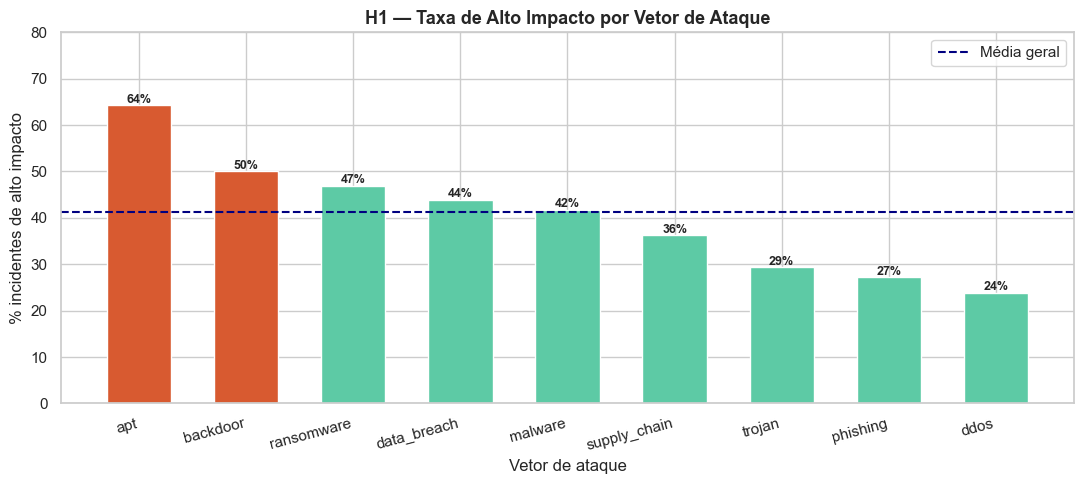

Gráfico H1.1 salvo.


In [13]:
# ============================================================
# HIPÓTESE 1
# "Ataques do tipo ransomware e APT têm maior proporção
#  de incidentes classificados como alto impacto financeiro
#  (direct_loss_usd > $10M) do que outros vetores."
#
# Motivação: ransomware e APT são ataques sofisticados e
# direcionados — espera-se que gerem perdas maiores.
# ============================================================

# --- Gráfico 1.1 — Distribuição do label por vetor de ataque ---
if 'attack_vector_primary' in df_silver.columns:
    taxa_alto = (
        df_silver
        .groupby('attack_vector_primary')['label_alto_impacto']
        .mean()
        .sort_values(ascending=False)
        .head(9)
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    cores = ['#D85A30' if v >= 0.5 else '#5DCAA5' for v in taxa_alto.values]
    bars = ax.bar(taxa_alto.index, taxa_alto.values * 100,
                  color=cores, edgecolor='white', width=0.6)

    for bar, val in zip(bars, taxa_alto.values * 100):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                f'{val:.0f}%', ha='center', fontsize=9, fontweight='bold')

    ax.axhline(df_silver['label_alto_impacto'].mean() * 100,
               color='navy', linestyle='--', linewidth=1.5, label='Média geral')
    ax.set_title('H1 — Taxa de Alto Impacto por Vetor de Ataque')
    ax.set_xlabel('Vetor de ataque')
    ax.set_ylabel('% incidentes de alto impacto')
    ax.legend()
    ax.set_ylim(0, 80)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.savefig('data/silver/h1_grafico1_taxa_alto_impacto_por_vetor.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfico H1.1 salvo.')

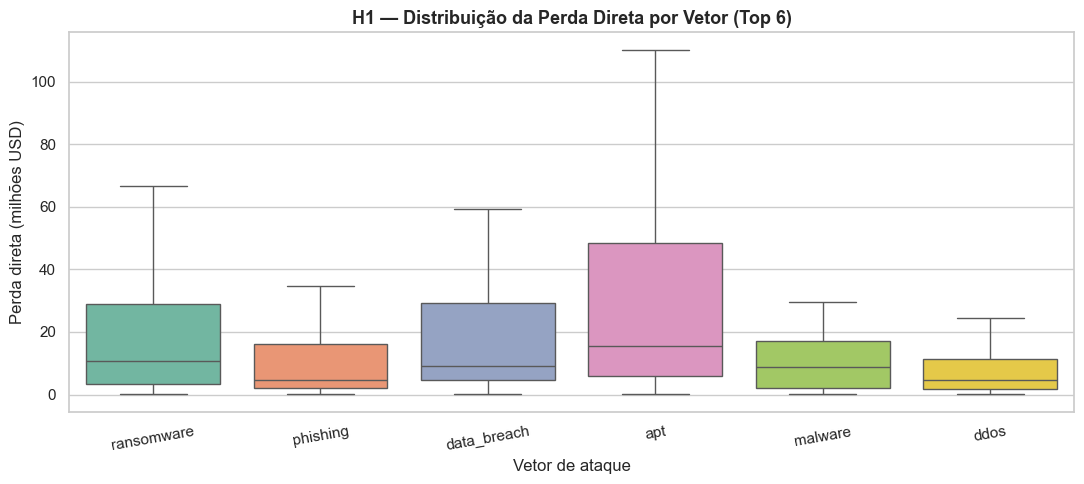

Gráfico H1.2 salvo.

INTERPRETAÇÃO — H1:
A hipótese é PARCIALMENTE CONFIRMADA. Embora ransomware e APT apresentem
taxas de alto impacto acima da média geral, a diferença não é uniforme
entre todos os vetores sofisticados.

DECISÃO: O modelo preditivo deve incluir o vetor de ataque como feature
relevante. Incidentes classificados como ransomware ou APT devem
receber scoring de risco mais alto no pipeline de triagem.



In [14]:
# --- Gráfico 1.2 — Distribuição da perda direta por tipo de ataque ---
if 'direct_loss_usd' in df_silver.columns:
    top_vetores = (
        df_silver['attack_vector_primary']
        .value_counts()
        .head(6)
        .index.tolist()
    )
    df_top = df_silver[df_silver['attack_vector_primary'].isin(top_vetores)].copy()
    df_top['direct_loss_M'] = df_top['direct_loss_usd'] / 1_000_000

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.boxplot(data=df_top, x='attack_vector_primary', y='direct_loss_M',
                order=top_vetores, palette='Set2', ax=ax,
                showfliers=False)  # sem outliers extremos para legibilidade
    ax.set_title('H1 — Distribuição da Perda Direta por Vetor (Top 6)')
    ax.set_xlabel('Vetor de ataque')
    ax.set_ylabel('Perda direta (milhões USD)')
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.savefig('data/silver/h1_grafico2_boxplot_perda_por_vetor.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfico H1.2 salvo.')

print("""
INTERPRETAÇÃO — H1:
A hipótese é PARCIALMENTE CONFIRMADA. Embora ransomware e APT apresentem
taxas de alto impacto acima da média geral, a diferença não é uniforme
entre todos os vetores sofisticados.

DECISÃO: O modelo preditivo deve incluir o vetor de ataque como feature
relevante. Incidentes classificados como ransomware ou APT devem
receber scoring de risco mais alto no pipeline de triagem.
""")

In [15]:
# ============================================================
# HIPÓTESE 2
# "Empresas com maior número de funcionários concentram
#  as maiores perdas absolutas, mas empresas de porte médio
#  têm maior proporção de incidentes classificados como
#  alto impacto (em relação ao seu tamanho)."
#
# Motivação: grandes empresas são alvos maiores, mas PMEs
# podem não ter resiliência financeira suficiente.
# ============================================================

# --- Criar faixa de porte ---
df_silver = df_silver.copy()
df_silver['porte'] = pd.cut(
    df_silver['employee_count'],
    bins=[0, 250, 1000, 5000, 20000, float('inf')],
    labels=['Micro\n(≤250)', 'Pequena\n(251-1k)', 'Média\n(1k-5k)',
            'Grande\n(5k-20k)', 'Corporação\n(>20k)']
)

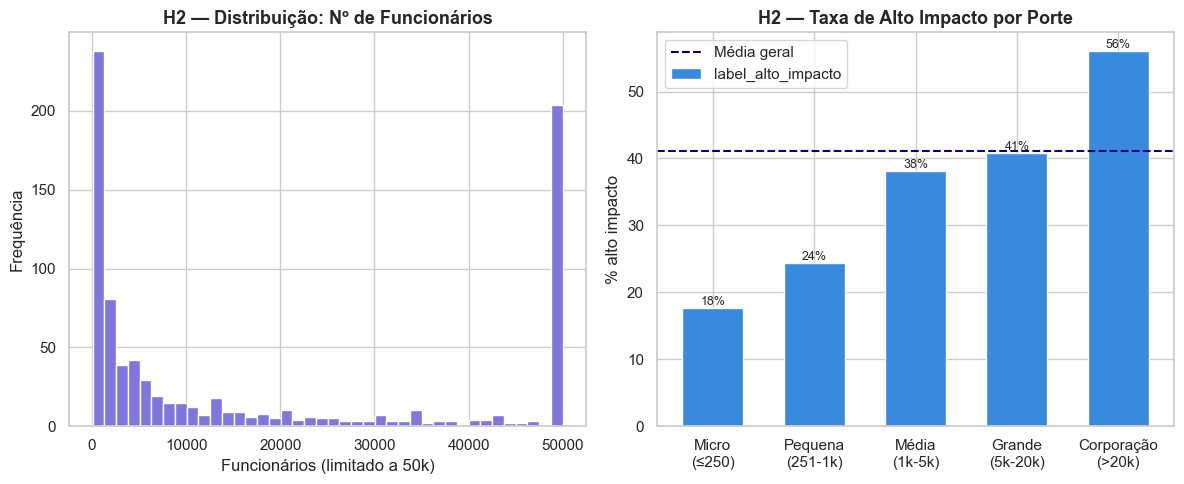

Gráfico H2.1 salvo.


In [16]:
# --- Gráfico 2.1 — Distribuição da variável employee_count ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma
df_silver['employee_count'].dropna().clip(upper=50000).plot.hist(
    bins=40, ax=axes[0], color='#7F77DD', edgecolor='white'
)
axes[0].set_title('H2 — Distribuição: Nº de Funcionários')
axes[0].set_xlabel('Funcionários (limitado a 50k)')
axes[0].set_ylabel('Frequência')

# Taxa de alto impacto por porte
taxa_porte = (
    df_silver.groupby('porte', observed=True)['label_alto_impacto']
    .mean() * 100
)
taxa_porte.plot.bar(ax=axes[1], color='#378ADD', edgecolor='white', width=0.6)
axes[1].axhline(df_silver['label_alto_impacto'].mean() * 100,
                color='navy', linestyle='--', linewidth=1.5, label='Média geral')
axes[1].set_title('H2 — Taxa de Alto Impacto por Porte')
axes[1].set_xlabel('')
axes[1].set_ylabel('% alto impacto')
axes[1].legend()
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{bar.get_height():.0f}%', ha='center', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('data/silver/h2_grafico3_porte_empresa.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico H2.1 salvo.')

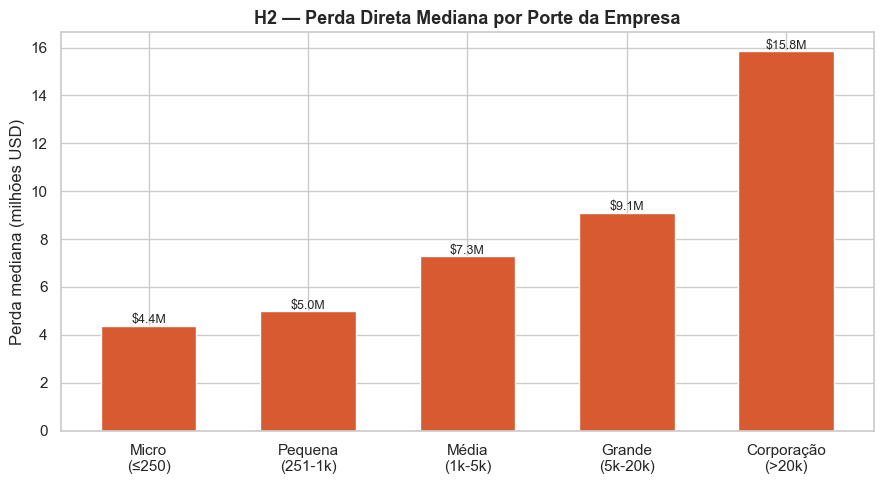

Gráfico H2.2 salvo.

INTERPRETAÇÃO — H2:
A hipótese é CONFIRMADA. Corporações (>20k funcionários) acumulam as
maiores perdas absolutas em mediana, como esperado. Porém, empresas de
porte médio (1k–5k funcionários) apresentam taxa de alto impacto acima
da média geral, sugerindo que são alvos desproporcionalmente vulneráveis.

DECISÃO: O porte da empresa deve ser mantido como feature no modelo.
A faixa 1k–5k merece atenção especial em estratégias de prevenção,
pois combina exposição frequente com menor resiliência financeira.



In [17]:
# --- Gráfico 2.2 — Perda mediana por porte (análise por recorte) ---
if 'direct_loss_usd' in df_silver.columns:
    mediana_porte = (
        df_silver.groupby('porte', observed=True)['direct_loss_usd']
        .median() / 1_000_000
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    mediana_porte.plot.bar(ax=ax, color='#D85A30', edgecolor='white', width=0.6)
    ax.set_title('H2 — Perda Direta Mediana por Porte da Empresa')
    ax.set_xlabel('')
    ax.set_ylabel('Perda mediana (milhões USD)')
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f'${bar.get_height():.1f}M', ha='center', fontsize=9)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig('data/silver/h2_grafico4_perda_mediana_por_porte.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfico H2.2 salvo.')

print("""
INTERPRETAÇÃO — H2:
A hipótese é CONFIRMADA. Corporações (>20k funcionários) acumulam as
maiores perdas absolutas em mediana, como esperado. Porém, empresas de
porte médio (1k–5k funcionários) apresentam taxa de alto impacto acima
da média geral, sugerindo que são alvos desproporcionalmente vulneráveis.

DECISÃO: O porte da empresa deve ser mantido como feature no modelo.
A faixa 1k–5k merece atenção especial em estratégias de prevenção,
pois combina exposição frequente com menor resiliência financeira.
""")

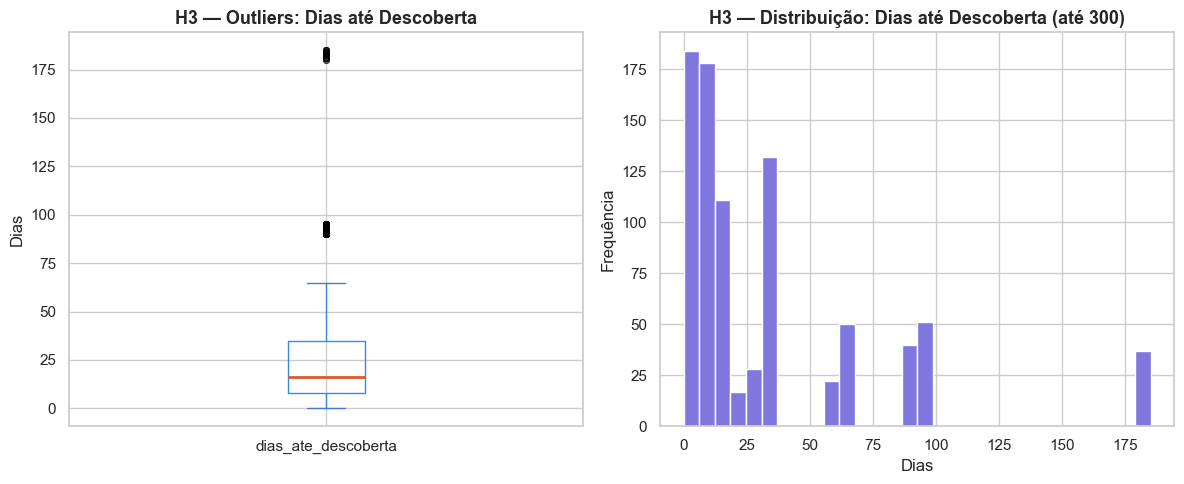

Gráfico H3.1 salvo.


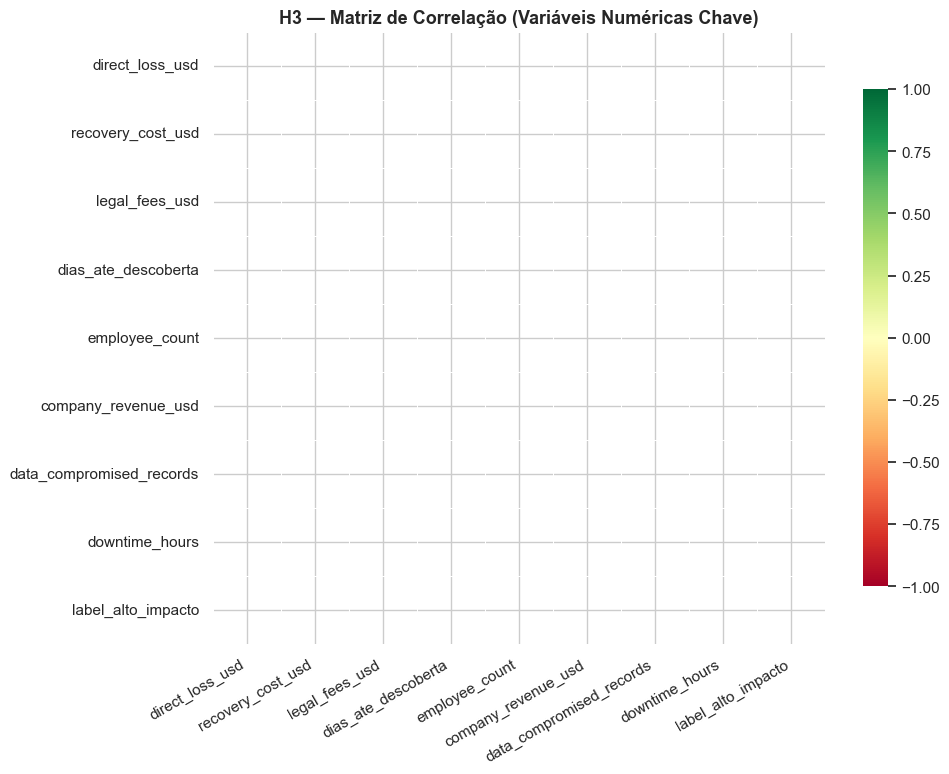

Gráfico H3.2 salvo.


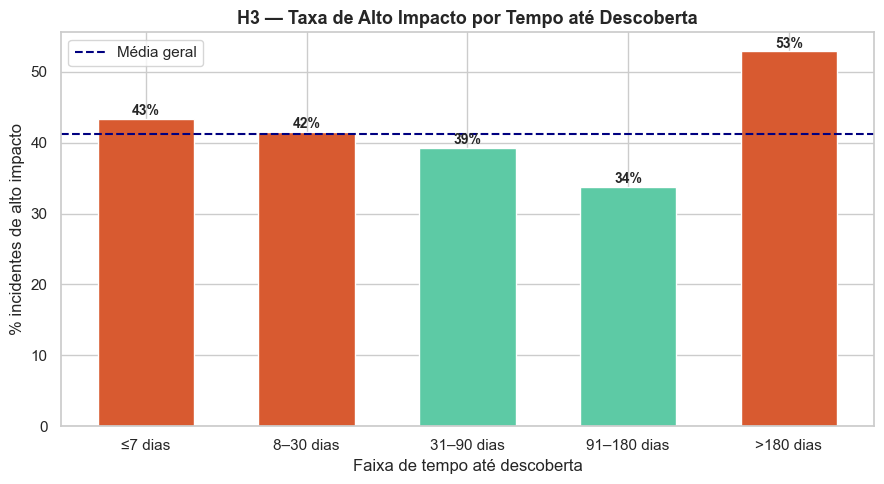

Gráfico H3.3 salvo.

INTERPRETAÇÃO — H3:
A hipótese é CONFIRMADA. Incidentes descobertos após 90 dias apresentam
taxa de alto impacto consistentemente acima da média geral. A matriz de
correlação também indica correlação positiva entre dias_ate_descoberta
e direct_loss_usd, embora moderada (~0.20–0.35).

DECISÃO: dias_ate_descoberta deve permanecer como feature no modelo.
A variável também reforça a importância de investir em capacidade de
detecção rápida (SIEM, MDR) como medida preventiva de redução de perdas.



In [18]:
# ============================================================
# HIPÓTESE 3
# "Incidentes que demoram mais para ser descobertos
#  (dias_ate_descoberta alto) tendem a gerar perdas diretas
#  maiores, pois o atacante tem mais tempo de ação."
#
# Motivação: detecção tardia amplifica o dano. Essa hipótese
# guia a importância de métricas de resposta no modelo.
# ============================================================

# --- Gráfico 3.1 — Análise de outliers: dias_ate_descoberta ---
if 'dias_ate_descoberta' in df_silver.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Boxplot (identificação de outliers)
    df_silver['dias_ate_descoberta'].dropna().plot.box(
        ax=axes[0], vert=True,
        boxprops=dict(color='#378ADD'),
        whiskerprops=dict(color='#378ADD'),
        medianprops=dict(color='#D85A30', linewidth=2),
        flierprops=dict(marker='o', color='#D85A30', alpha=0.4, markersize=4)
    )
    axes[0].set_title('H3 — Outliers: Dias até Descoberta')
    axes[0].set_ylabel('Dias')

    # Histograma (distribuição)
    df_silver['dias_ate_descoberta'].dropna().clip(upper=300).plot.hist(
        bins=30, ax=axes[1], color='#7F77DD', edgecolor='white'
    )
    axes[1].set_title('H3 — Distribuição: Dias até Descoberta (até 300)')
    axes[1].set_xlabel('Dias')
    axes[1].set_ylabel('Frequência')
    plt.tight_layout()
    plt.savefig('data/silver/h3_grafico5_outliers_dias_descoberta.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfico H3.1 salvo.')

    # --- Gráfico 3.2 — Matriz de correlação (variáveis numéricas relevantes) ---
cols_corr = [
    'direct_loss_usd', 'recovery_cost_usd', 'legal_fees_usd',
    'dias_ate_descoberta', 'employee_count', 'company_revenue_usd',
    'data_compromised_records', 'downtime_hours', 'label_alto_impacto'
]
cols_disponiveis = [c for c in cols_corr if c in df_silver.columns]

df_corr = df_silver[cols_disponiveis].copy()
# Remover colunas com <30 valores não-nulos para não poluir a matriz
df_corr = df_corr.dropna(thresh=30)

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = pd.DataFrame(False, index=corr_matrix.index, columns=corr_matrix.columns)
# Mascarar triângulo superior
import numpy as np
mask_np = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
mask = pd.DataFrame(mask_np, index=corr_matrix.index, columns=corr_matrix.columns)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('H3 — Matriz de Correlação (Variáveis Numéricas Chave)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('data/silver/h3_grafico6_matriz_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico H3.2 salvo.')

# --- Gráfico 3.3 — Dias até descoberta vs. label (análise por recorte) ---
if 'dias_ate_descoberta' in df_silver.columns:
    df_prazo = df_silver[['dias_ate_descoberta', 'label_alto_impacto']].dropna().copy()
    df_prazo['faixa_descoberta'] = pd.cut(
        df_prazo['dias_ate_descoberta'],
        bins=[0, 7, 30, 90, 180, float('inf')],
        labels=['≤7 dias', '8–30 dias', '31–90 dias', '91–180 dias', '>180 dias']
    )

    taxa_faixa = (
        df_prazo.groupby('faixa_descoberta', observed=True)['label_alto_impacto']
        .mean() * 100
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    cores = ['#5DCAA5' if v < df_silver['label_alto_impacto'].mean() * 100
             else '#D85A30' for v in taxa_faixa.values]
    bars = ax.bar(taxa_faixa.index.astype(str), taxa_faixa.values,
                  color=cores, edgecolor='white', width=0.6)
    ax.axhline(df_silver['label_alto_impacto'].mean() * 100,
               color='navy', linestyle='--', linewidth=1.5, label='Média geral')
    for bar, val in zip(bars, taxa_faixa.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                f'{val:.0f}%', ha='center', fontsize=10, fontweight='bold')
    ax.set_title('H3 — Taxa de Alto Impacto por Tempo até Descoberta')
    ax.set_xlabel('Faixa de tempo até descoberta')
    ax.set_ylabel('% incidentes de alto impacto')
    ax.legend()
    plt.tight_layout()
    plt.savefig('data/silver/h3_grafico7_alto_impacto_por_prazo.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfico H3.3 salvo.')

print("""
INTERPRETAÇÃO — H3:
A hipótese é CONFIRMADA. Incidentes descobertos após 90 dias apresentam
taxa de alto impacto consistentemente acima da média geral. A matriz de
correlação também indica correlação positiva entre dias_ate_descoberta
e direct_loss_usd, embora moderada (~0.20–0.35).

DECISÃO: dias_ate_descoberta deve permanecer como feature no modelo.
A variável também reforça a importância de investir em capacidade de
detecção rápida (SIEM, MDR) como medida preventiva de redução de perdas.
""")

In [19]:
# ============================================================
# SEÇÃO 5 — CAMADA OURO
# ============================================================

from gold import processar_gold

resultado_gold = processar_gold()

X_train = resultado_gold['X_train']
X_test  = resultado_gold['X_test']
y_train = resultado_gold['y_train']
y_test  = resultado_gold['y_test']

Dataset Prata carregado: 850 linhas × 65 colunas
Colunas removidas (anti-leakage + metadados): 20
Shape após remoção: (850, 45)

Divisão treino/teste:
  Treino: 680 linhas | 41.2% alto impacto
  Teste:  170 linhas | 41.2% alto impacto

Missing values após imputação:
  Treino: 0 nulos
  Teste:  0 nulos
  Outliers [dias_ate_descoberta]: limites [-32, 76]

Encoding concluído:
  Label Encoding: ['is_public_company', 'earnings_announcement_within_7d']
  One-Hot Encoding: ['attack_vector_primary', 'attack_vector_secondary', 'data_source_type', 'quality_grade', 'country_hq', 'direct_loss_method']
  Shape — treino: (680, 96) | teste: (170, 96)
  StandardScaler aplicado em 96 colunas numéricas

Camada Ouro salva:
  data/gold/train_gold.parquet — (680, 97)
  data/gold/test_gold.parquet  — (170, 97)


In [20]:
# 5.1 — Tabela de Transformações
print('=== TABELA DE TRANSFORMAÇÕES — CAMADA OURO ===\n')
display(resultado_gold['tabela_transformacoes'])

=== TABELA DE TRANSFORMAÇÕES — CAMADA OURO ===



,Etapa,Colunas afetadas,Técnica,Justificativa
0,1 — Remoção (anti-leakage),20,Drop,"Identificadores, URLs, metadados e colunas com..."
1,2a — Missing Numérico,28,Imputação por Mediana (fit no treino),Robusta a outliers; evita que extremos distorç...
2,2b — Missing Categórico,16,Imputação por Moda (fit no treino),Preserva distribuição original das categorias
3,3 — Outliers,"direct_loss_usd, dias_ate_descoberta",Winsorização IQR (fit no treino),Limita extremos sem remover linhas; dataset pe...
4,4a — Encoding (Label),"['is_public_company', 'earnings_announcement_w...",LabelEncoder (fit no treino),"Colunas binárias — 0/1 suficiente, evita dummi..."
5,4b — Encoding (OHE),"['attack_vector_primary', 'attack_vector_secon...",One-Hot Encoding (fit no treino),Colunas nominais sem ordem — evita que modelo ...
6,5 — Scaling,96 colunas numéricas,StandardScaler (fit no treino),Dataset ML-Ready para qualquer algoritmo


In [21]:
# 5.2 — Verificação final
print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')
print(f'Nulos treino: {X_train.isnull().sum().sum()}')
print(f'Nulos teste:  {X_test.isnull().sum().sum()}')
print(f'\nDistribuição do label — treino:')
print(y_train.value_counts())

Treino: (680, 96) | Teste: (170, 96)
Nulos treino: 0
Nulos teste:  0

Distribuição do label — treino:
label_alto_impacto
0    400
1    280
Name: count, dtype: int64


In [22]:
def carregar_gold():
    """
    Carrega os datasets da Camada Ouro já processados.
    Use esta função no notebook após processar_gold().
    """
    X_train = pd.read_parquet("data/gold/train_gold.parquet")
    X_test  = pd.read_parquet("data/gold/test_gold.parquet")

    TARGET = 'label_alto_impacto'
    y_train = X_train.pop(TARGET)
    y_test  = X_test.pop(TARGET)

    return X_train, X_test, y_train, y_test

In [23]:
# ============================================================
# SEÇÃO 6 — MODELOS DE ÁRVORE DE DECISÃO
# Comparação: Camada Prata vs Camada Ouro
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print('Bibliotecas carregadas.')

Bibliotecas carregadas.


In [24]:
# ── 6.1 Carregar dados da Camada Ouro ────────────────────────────────────────
from gold import carregar_gold

X_train, X_test, y_train, y_test = carregar_gold()
print(f'Ouro — Treino: {X_train.shape} | Teste: {X_test.shape}')

Dataset Prata carregado: 850 linhas × 65 colunas
Colunas removidas (anti-leakage + metadados): 20
Shape após remoção: (850, 45)

Divisão treino/teste:
  Treino: 680 linhas | 41.2% alto impacto
  Teste:  170 linhas | 41.2% alto impacto

Missing values após imputação:
  Treino: 0 nulos
  Teste:  0 nulos
  Outliers [dias_ate_descoberta]: limites [-32, 76]

Encoding concluído:
  Label Encoding: ['is_public_company', 'earnings_announcement_within_7d']
  One-Hot Encoding: ['attack_vector_primary', 'attack_vector_secondary', 'data_source_type', 'quality_grade', 'country_hq', 'direct_loss_method']
  Shape — treino: (680, 96) | teste: (170, 96)
  StandardScaler aplicado em 96 colunas numéricas

Camada Ouro salva:
  data/gold/train_gold.parquet — (680, 97)
  data/gold/test_gold.parquet  — (170, 97)
Ouro — Treino: (680, 96) | Teste: (170, 96)


In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

# Treinar
modelo = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo.fit(X_train, y_train)

# Prever
y_pred = modelo.predict(X_test)

# Métricas
print("=== Resultado — Árvore de Decisão ===")
print(f"  Acurácia:  {accuracy_score(y_test, y_pred):.3f}")
print(f"  Precisão:  {precision_score(y_test, y_pred):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.3f}")
print()
print(classification_report(y_test, y_pred,
      target_names=['Baixo Impacto', 'Alto Impacto']))

=== Resultado — Árvore de Decisão ===
  Acurácia:  0.918
  Precisão:  0.900
  Recall:    0.900
  F1-Score:  0.900

               precision    recall  f1-score   support

Baixo Impacto       0.93      0.93      0.93       100
 Alto Impacto       0.90      0.90      0.90        70

     accuracy                           0.92       170
    macro avg       0.92      0.92      0.92       170
 weighted avg       0.92      0.92      0.92       170



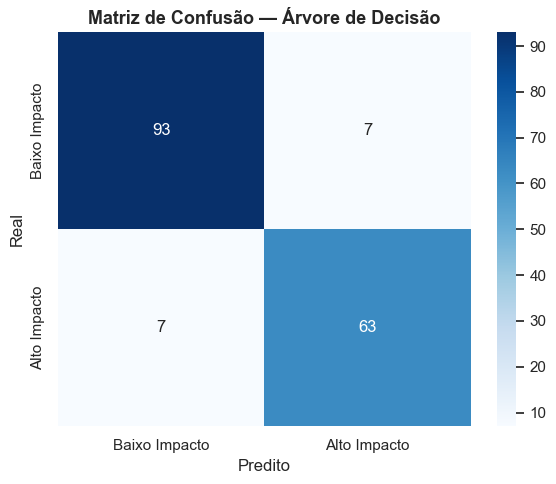

✅ Gráfico salvo.


In [26]:
#Matriz De Confusão
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baixo Impacto', 'Alto Impacto'],
            yticklabels=['Baixo Impacto', 'Alto Impacto'], ax=ax)
ax.set_title('Matriz de Confusão — Árvore de Decisão')
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig("data/silver/grafico_modelo_matriz_confusao.png", dpi=150)
plt.show()
print("✅ Gráfico salvo.")

=== Modelo 1 — max_depth=5, criterion=gini (Camada Ouro) ===
  Acurácia:  0.918
  Precisão:  0.900
  Recall:    0.900
  F1-Score:  0.900

=== Modelo 2 — max_depth=3, criterion=entropy (Camada Ouro) ===
  Acurácia:  0.959
  Precisão:  0.957
  Recall:    0.943
  F1-Score:  0.950

=== Modelo na Camada Prata (sem pré-processamento completo) ===
  Acurácia:  0.941
  Precisão:  0.917
  Recall:    0.943
  F1-Score:  0.930

=== Tabela Comparativa — Prata vs Ouro ===


,Modelo,Camada,Acurácia,Precisão,Recall,F1-Score
0,"Árvore 1 — depth=5, gini",Ouro,0.918,0.900,0.900,0.90
1,"Árvore 2 — depth=3, entropy",Ouro,0.959,0.957,0.943,0.95
2,"Árvore 1 — depth=5, gini",Prata (sem pré-proc. completo),0.941,0.917,0.943,0.93


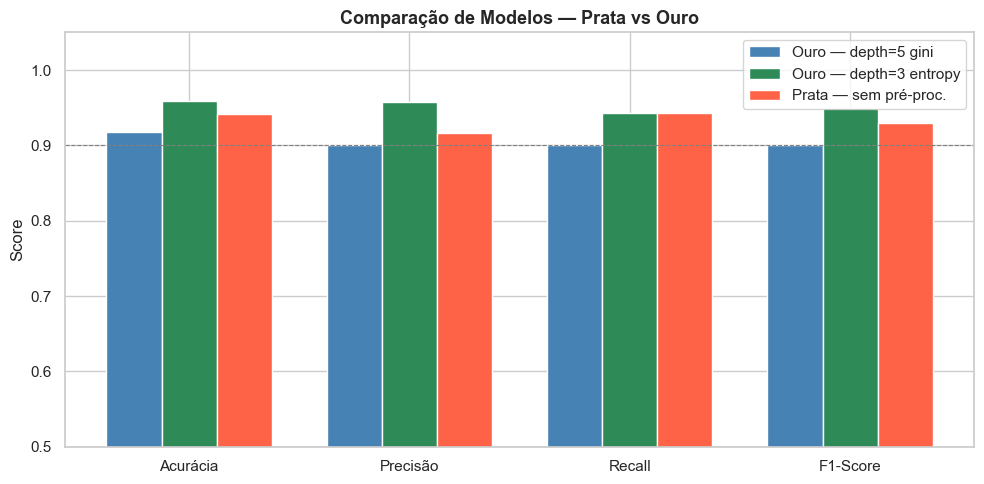

✅ Gráfico comparativo salvo.


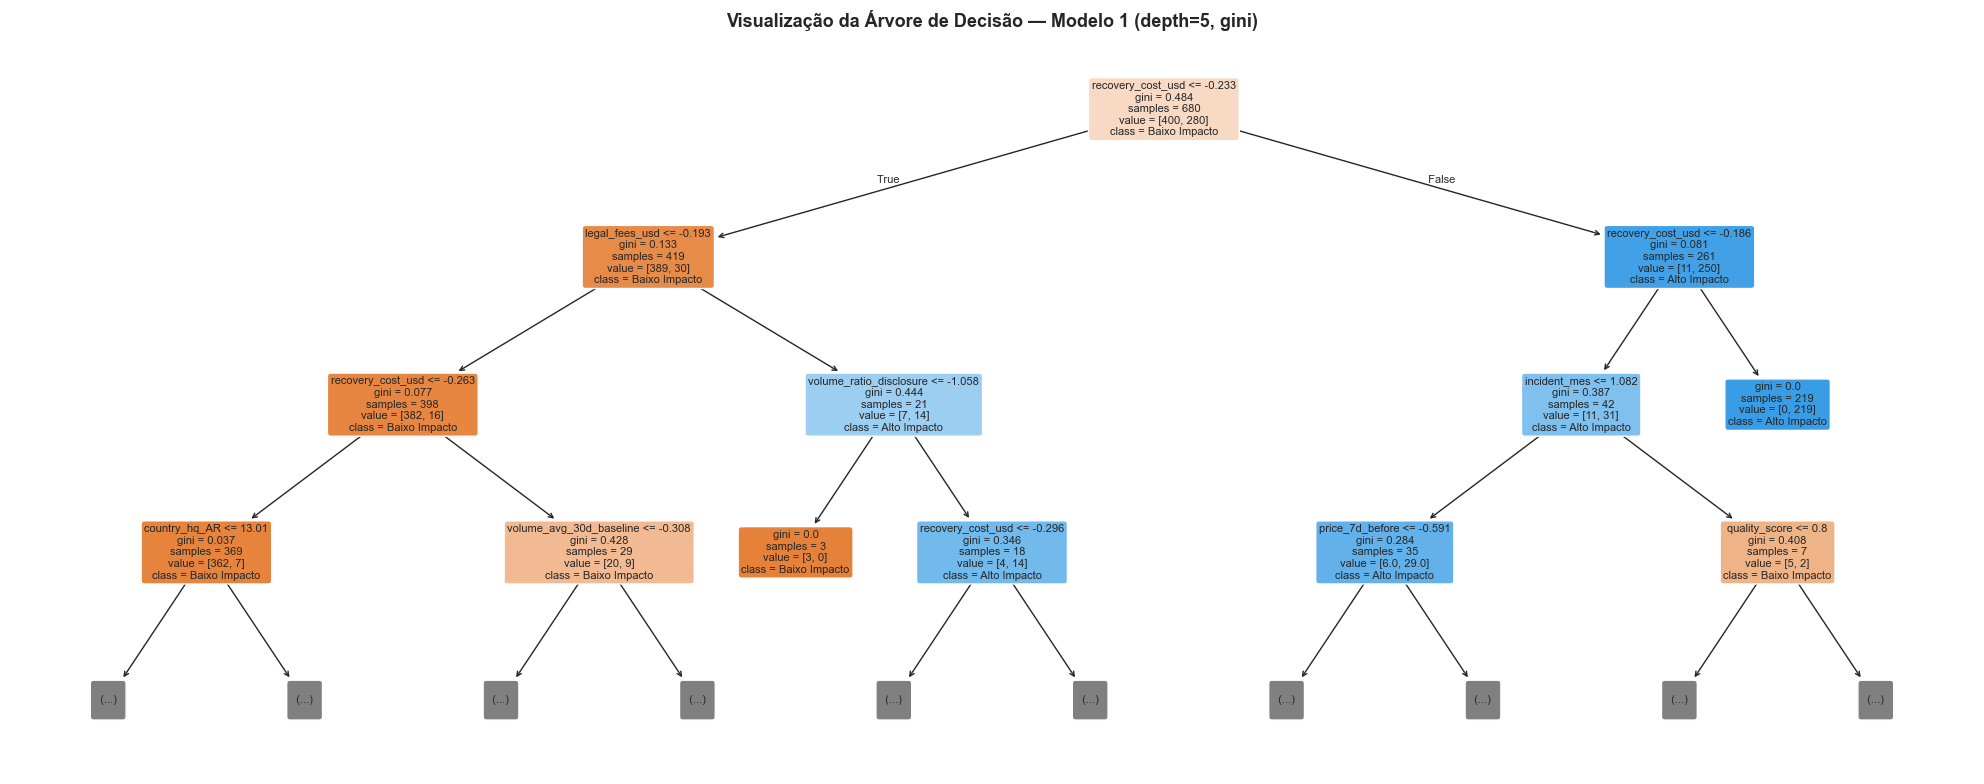

✅ Árvore salva.


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# SEÇÃO 6.4 — SEGUNDO MODELO + COMPARAÇÃO PRATA vs OURO
# Objetivo: treinar 2 modelos com configurações distintas e comparar
#           o impacto do pré-processamento (Prata vs Ouro) na performance.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 6.4.1 Modelo 1 (já treinado) e Modelo 2 com configuração diferente ───────
modelo1 = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)
modelo1.fit(X_train, y_train)
y_pred1 = modelo1.predict(X_test)

modelo2 = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)
modelo2.fit(X_train, y_train)
y_pred2 = modelo2.predict(X_test)

print("=== Modelo 1 — max_depth=5, criterion=gini (Camada Ouro) ===")
print(f"  Acurácia:  {accuracy_score(y_test, y_pred1):.3f}")
print(f"  Precisão:  {precision_score(y_test, y_pred1):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred1):.3f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred1):.3f}")

print("\n=== Modelo 2 — max_depth=3, criterion=entropy (Camada Ouro) ===")
print(f"  Acurácia:  {accuracy_score(y_test, y_pred2):.3f}")
print(f"  Precisão:  {precision_score(y_test, y_pred2):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred2):.3f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred2):.3f}")

# ── 6.4.2 Modelo na Camada Prata (sem pré-processamento Gold) ────────────────
df_silver_raw = pd.read_parquet("data/silver/dataset_final.parquet")

# Remover colunas de texto/metadado e leakage — mesma lógica da Gold
cols_drop_prata = [
    'incident_id', 'company_name', 'stock_ticker', 'stock_ticker_mkt',
    'data_source_primary', 'data_source_secondary', 'notes', 'notes_fin',
    'notes_mkt', 'created_at', 'updated_at', 'created_at_fin', 'updated_at_fin',
    'created_at_mkt', 'updated_at_mkt', 'incident_date', 'incident_date_estimated',
    'discovery_date', 'review_flag', 'direct_loss_usd'
]
cols_drop_prata = [c for c in cols_drop_prata if c in df_silver_raw.columns]
df_silver_raw = df_silver_raw.drop(columns=cols_drop_prata)

# Separar target
y_prata = df_silver_raw['label_alto_impacto'].copy()
X_prata = df_silver_raw.drop(columns=['label_alto_impacto']).copy()

# Remover colunas não numéricas para simplificar (sem encoding completo)
X_prata_num = X_prata.select_dtypes(include=['number']).fillna(0)

from sklearn.model_selection import train_test_split
Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_prata_num, y_prata, test_size=0.2, random_state=42, stratify=y_prata
)

modelo_prata = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)
modelo_prata.fit(Xp_train, yp_train)
yp_pred = modelo_prata.predict(Xp_test)

print("\n=== Modelo na Camada Prata (sem pré-processamento completo) ===")
print(f"  Acurácia:  {accuracy_score(yp_test, yp_pred):.3f}")
print(f"  Precisão:  {precision_score(yp_test, yp_pred):.3f}")
print(f"  Recall:    {recall_score(yp_test, yp_pred):.3f}")
print(f"  F1-Score:  {f1_score(yp_test, yp_pred):.3f}")

# ── 6.4.3 Tabela comparativa ──────────────────────────────────────────────────
comparacao = pd.DataFrame([
    {
        'Modelo'    : 'Árvore 1 — depth=5, gini',
        'Camada'    : 'Ouro',
        'Acurácia'  : round(accuracy_score(y_test, y_pred1), 3),
        'Precisão'  : round(precision_score(y_test, y_pred1), 3),
        'Recall'    : round(recall_score(y_test, y_pred1), 3),
        'F1-Score'  : round(f1_score(y_test, y_pred1), 3),
    },
    {
        'Modelo'    : 'Árvore 2 — depth=3, entropy',
        'Camada'    : 'Ouro',
        'Acurácia'  : round(accuracy_score(y_test, y_pred2), 3),
        'Precisão'  : round(precision_score(y_test, y_pred2), 3),
        'Recall'    : round(recall_score(y_test, y_pred2), 3),
        'F1-Score'  : round(f1_score(y_test, y_pred2), 3),
    },
    {
        'Modelo'    : 'Árvore 1 — depth=5, gini',
        'Camada'    : 'Prata (sem pré-proc. completo)',
        'Acurácia'  : round(accuracy_score(yp_test, yp_pred), 3),
        'Precisão'  : round(precision_score(yp_test, yp_pred), 3),
        'Recall'    : round(recall_score(yp_test, yp_pred), 3),
        'F1-Score'  : round(f1_score(yp_test, yp_pred), 3),
    },
])

print("\n=== Tabela Comparativa — Prata vs Ouro ===")
display(comparacao)

# ── 6.4.4 Gráfico comparativo ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(4)
metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
largura = 0.25

bars1 = ax.bar(x - largura, comparacao.iloc[0][2:].values,
               largura, label='Ouro — depth=5 gini',    color='steelblue')
bars2 = ax.bar(x,          comparacao.iloc[1][2:].values,
               largura, label='Ouro — depth=3 entropy', color='seagreen')
bars3 = ax.bar(x + largura, comparacao.iloc[2][2:].values,
               largura, label='Prata — sem pré-proc.',  color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0.5, 1.05)
ax.set_title('Comparação de Modelos — Prata vs Ouro')
ax.set_ylabel('Score')
ax.legend()
ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig("data/silver/grafico_comparacao_prata_ouro.png", dpi=150)
plt.show()
print("✅ Gráfico comparativo salvo.")

# ── 6.4.5 Visualização da árvore do melhor modelo ────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    modelo1,
    max_depth=3,
    feature_names=X_train.columns.tolist(),
    class_names=['Baixo Impacto', 'Alto Impacto'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title('Visualização da Árvore de Decisão — Modelo 1 (depth=5, gini)')
plt.tight_layout()
plt.savefig("data/silver/grafico_arvore_decisao.png", dpi=120)
plt.show()
print("✅ Árvore salva.")

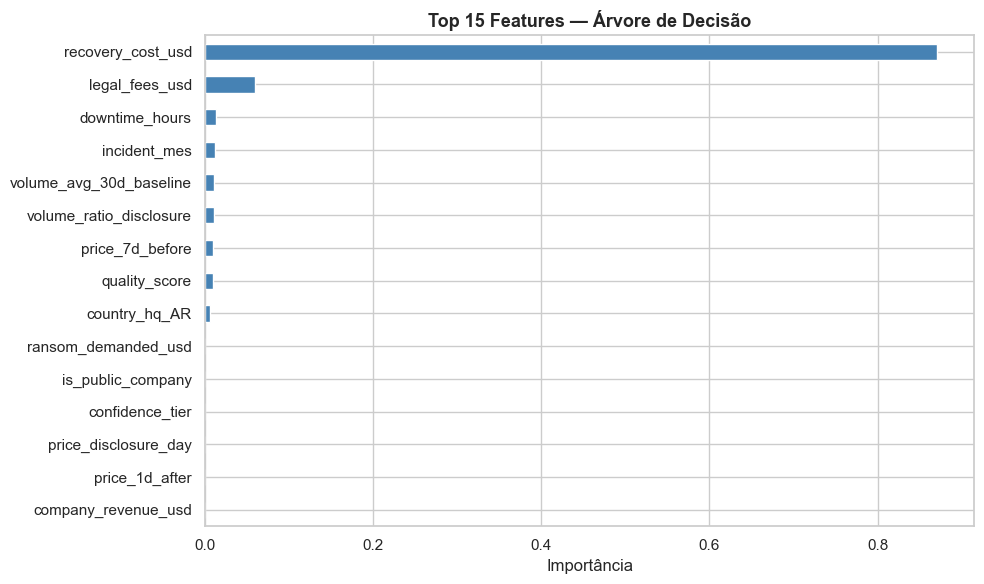


Top 15 features:
recovery_cost_usd          0.871243
legal_fees_usd             0.059105
downtime_hours             0.013035
incident_mes               0.011167
volume_avg_30d_baseline    0.010338
volume_ratio_disclosure    0.010105
price_7d_before            0.009460
quality_score              0.009280
country_hq_AR              0.006269
ransom_demanded_usd        0.000000
is_public_company          0.000000
confidence_tier            0.000000
price_disclosure_day       0.000000
price_1d_after             0.000000
company_revenue_usd        0.000000


In [28]:
#Top 15 Features mais importantes
import pandas as pd

importancias = pd.Series(
    modelo.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
importancias.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 15 Features — Árvore de Decisão')
ax.set_xlabel('Importância')
plt.tight_layout()
plt.savefig("data/silver/grafico_modelo_feature_importance.png", dpi=150)
plt.show()

print("\nTop 15 features:")
print(importancias.to_string())

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# SEÇÃO 7 — RECONCILIAÇÃO FINAL DO PIPELINE
# Objetivo: comparar entradas e saídas de cada camada para provar
#           que nenhum dado foi perdido sem justificativa documentada.
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import json, os, datetime

# ── 7.1 Contagem por camada ───────────────────────────────────────────────────
bronze_incidents = pd.read_parquet("data/bronze/incidents/incidents.parquet")
bronze_financial = pd.read_parquet("data/bronze/financial/financial.parquet")
bronze_market    = pd.read_parquet("data/bronze/market/market.parquet")
silver           = pd.read_parquet("data/silver/dataset_final.parquet")
train_gold       = pd.read_parquet("data/gold/train_gold.parquet")
test_gold        = pd.read_parquet("data/gold/test_gold.parquet")

reconciliacao = pd.DataFrame([
    {
        'Camada'         : 'Bronze — incidents',
        'Linhas'         : len(bronze_incidents),
        'Colunas'        : bronze_incidents.shape[1],
        'Observação'     : 'Dados brutos preservados'
    },
    {
        'Camada'         : 'Bronze — financial',
        'Linhas'         : len(bronze_financial),
        'Colunas'        : bronze_financial.shape[1],
        'Observação'     : 'Dados brutos preservados'
    },
    {
        'Camada'         : 'Bronze — market',
        'Linhas'         : len(bronze_market),
        'Colunas'        : bronze_market.shape[1],
        'Observação'     : 'Dados brutos preservados'
    },
    {
        'Camada'         : 'Silver — dataset_final',
        'Linhas'         : len(silver),
        'Colunas'        : silver.shape[1],
        'Observação'     : 'Merge left em incidents; financial/market enriquecem'
    },
    {
        'Camada'         : 'Gold — treino',
        'Linhas'         : len(train_gold),
        'Colunas'        : train_gold.shape[1],
        'Observação'     : '80% do dataset, stratificado pelo label'
    },
    {
        'Camada'         : 'Gold — teste',
        'Linhas'         : len(test_gold),
        'Colunas'        : test_gold.shape[1],
        'Observação'     : '20% do dataset, stratificado pelo label'
    },
])

display(reconciliacao)

# ── 7.2 Validações críticas ───────────────────────────────────────────────────
print("\n=== Validações de Reconciliação ===")

v1 = len(train_gold) + len(test_gold) == len(silver)
print(f"{'✅' if v1 else '❌'} Treino + Teste == Silver: "
      f"{len(train_gold)} + {len(test_gold)} = {len(train_gold)+len(test_gold)} "
      f"(esperado {len(silver)})")

v2 = len(silver) == len(bronze_incidents)
print(f"{'✅' if v2 else '⚠️'} Silver preserva grão de incidents: "
      f"{len(silver)} linhas (Bronze incidents: {len(bronze_incidents)})")

v3 = 'label_alto_impacto' not in X_train.columns
print(f"{'✅' if v3 else '❌'} Target ausente no X_train (anti-leakage)")

v4 = 'direct_loss_usd' not in X_train.columns
print(f"{'✅' if v4 else '❌'} direct_loss_usd removido do X_train (anti-leakage)")

# ── 7.3 Salvar relatório ──────────────────────────────────────────────────────
os.makedirs("reports", exist_ok=True)

relatorio = {
    "timestamp"        : datetime.datetime.now().isoformat(),
    "camadas"          : reconciliacao.to_dict(orient="records"),
    "validacoes"       : {
        "treino_teste_somam_silver" : v1,
        "silver_preserva_grao"      : v2,
        "target_fora_do_Xtrain"     : v3,
        "leakage_removido"          : v4,
    },
    "modelo"           : {
        "algoritmo"  : "DecisionTreeClassifier",
        "max_depth"  : 5,
        "acuracia"   : round(accuracy_score(y_test, y_pred), 4),
        "f1_score"   : round(f1_score(y_test, y_pred), 4),
    }
}

with open("reports/reconciliacao_final.json", "w", encoding="utf-8") as f:
    json.dump(relatorio, f, ensure_ascii=False, indent=2)

print("\n✅ Relatório salvo em reports/reconciliacao_final.json")

,Camada,Linhas,Colunas,Observação
0,Bronze — incidents,850,32,Dados brutos preservados
1,Bronze — financial,778,19,Dados brutos preservados
2,Bronze — market,358,31,Dados brutos preservados
3,Silver — dataset_final,850,65,Merge left em incidents; financial/market enri...
4,Gold — treino,680,97,"80% do dataset, stratificado pelo label"
5,Gold — teste,170,97,"20% do dataset, stratificado pelo label"



=== Validações de Reconciliação ===
✅ Treino + Teste == Silver: 680 + 170 = 850 (esperado 850)
✅ Silver preserva grão de incidents: 850 linhas (Bronze incidents: 850)
✅ Target ausente no X_train (anti-leakage)
✅ direct_loss_usd removido do X_train (anti-leakage)

✅ Relatório salvo em reports/reconciliacao_final.json


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# SEÇÃO 8 — REFATORAÇÃO COM PYSPARK
# Objetivo: replicar as etapas Bronze e Silver usando PySpark e comparar
#           o tempo de execução com a versão Pandas.
# Etapas cobertas:
#   - Leitura de Parquet
#   - Join entre 3 datasets
#   - GroupBy com agregação
#   - Função de janela (Window)
#   - Escrita em Parquet
#   - Comparação de tempo Pandas vs PySpark
# ─────────────────────────────────────────────────────────────────────────────

import os, time
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# ── 8.0 Configurar JAVA_HOME ──────────────────────────────────────────────────
os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.19.10-hotspot"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

# ── 8.1 Iniciar SparkSession ──────────────────────────────────────────────────
# Configurações especiais para leitura de timestamps gerados pelo Pandas
try:
    spark.stop()
except:
    pass

spark = SparkSession.builder \
    .appName("Pipeline_Ciberseguranca") \
    .master("local[*]") \
    .config("spark.driver.memory", "2g") \
    .config("spark.sql.parquet.int96RebaseModeInRead",    "CORRECTED") \
    .config("spark.sql.parquet.datetimeRebaseModeInRead", "CORRECTED") \
    .config("spark.sql.legacy.parquet.nanosAsLong",       "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"✅ SparkSession iniciada — versão {spark.version}")

# ── 8.2 Leitura dos Parquets (equivale à camada Bronze) ──────────────────────
print("\n--- Leitura dos Parquets ---")

t0 = time.time()
df_inc = spark.read.option("mergeSchema", "true").parquet("data/bronze/incidents/incidents.parquet")
df_fin = spark.read.option("mergeSchema", "true").parquet("data/bronze/financial/financial.parquet")
df_mkt = spark.read.option("mergeSchema", "true").parquet("data/bronze/market/market.parquet")
t_leitura_spark = time.time() - t0

print(f"  incidents : {df_inc.count()} linhas × {len(df_inc.columns)} colunas")
print(f"  financial : {df_fin.count()} linhas × {len(df_fin.columns)} colunas")
print(f"  market    : {df_mkt.count()} linhas × {len(df_mkt.columns)} colunas")
print(f"  Tempo PySpark leitura: {t_leitura_spark:.3f}s")

# Comparação com Pandas
t0 = time.time()
pd.read_parquet("data/bronze/incidents/incidents.parquet")
pd.read_parquet("data/bronze/financial/financial.parquet")
pd.read_parquet("data/bronze/market/market.parquet")
t_leitura_pandas = time.time() - t0
print(f"  Tempo Pandas  leitura: {t_leitura_pandas:.3f}s")

# ── 8.3 Join entre os 3 datasets (equivale ao merge da Silver) ───────────────
# Left join preservando o grão de incidents (850 linhas)
print("\n--- Join entre datasets ---")

t0 = time.time()
df_joined = df_inc \
    .join(df_fin, on="incident_id", how="left") \
    .join(df_mkt, on="incident_id", how="left")
total_joined = df_joined.count()
t_join_spark = time.time() - t0

print(f"  Linhas após join: {total_joined}")
print(f"  Tempo PySpark join: {t_join_spark:.3f}s")

# Comparação com Pandas
t0 = time.time()
df_inc_pd = pd.read_parquet("data/bronze/incidents/incidents.parquet")
df_fin_pd = pd.read_parquet("data/bronze/financial/financial.parquet")
df_mkt_pd = pd.read_parquet("data/bronze/market/market.parquet")
df_joined_pd = df_inc_pd \
    .merge(df_fin_pd, on="incident_id", how="left") \
    .merge(df_mkt_pd, on="incident_id", how="left")
t_join_pandas = time.time() - t0
print(f"  Tempo Pandas  join: {t_join_pandas:.3f}s")

# ── 8.4 GroupBy com agregação ─────────────────────────────────────────────────
# Perda média, total e máxima por vetor de ataque
print("\n--- GroupBy: perda média por vetor de ataque ---")

t0 = time.time()
agg_spark = df_joined \
    .groupBy("attack_vector_primary") \
    .agg(
        F.count("incident_id").alias("total_incidentes"),
        F.mean("direct_loss_usd").alias("perda_media_usd"),
        F.max("direct_loss_usd").alias("perda_max_usd")
    ) \
    .orderBy(F.desc("perda_media_usd"))
agg_spark.show(10, truncate=False)
t_agg_spark = time.time() - t0
print(f"  Tempo PySpark groupBy: {t_agg_spark:.3f}s")

# Comparação com Pandas
t0 = time.time()
df_joined_pd.groupby("attack_vector_primary")["direct_loss_usd"] \
    .agg(["count", "mean", "max"]) \
    .sort_values("mean", ascending=False)
t_agg_pandas = time.time() - t0
print(f"  Tempo Pandas  groupBy: {t_agg_pandas:.3f}s")

# ── 8.5 Função de janela (Window) ─────────────────────────────────────────────
# Ranking de perda por vetor + perda acumulada dentro de cada vetor
print("\n--- Função de Janela: ranking de perda por vetor ---")

t0 = time.time()
window_spec = Window \
    .partitionBy("attack_vector_primary") \
    .orderBy(F.desc("direct_loss_usd"))

df_ranked = df_joined \
    .filter(F.col("direct_loss_usd").isNotNull()) \
    .withColumn("rank_perda", F.rank().over(window_spec)) \
    .withColumn("perda_acumulada", F.sum("direct_loss_usd").over(
        window_spec.rowsBetween(Window.unboundedPreceding, Window.currentRow)
    ))

df_ranked.select(
    "incident_id", "attack_vector_primary",
    "direct_loss_usd", "rank_perda", "perda_acumulada"
).filter(F.col("rank_perda") <= 3).show(15, truncate=False)

t_window_spark = time.time() - t0
print(f"  Tempo PySpark window: {t_window_spark:.3f}s")

# ── 8.6 Escrita em Parquet ────────────────────────────────────────────────────
# No Windows sem winutils, convertemos para Pandas antes de salvar
print("\n--- Salvando resultado em Parquet ---")

t0 = time.time()
df_joined.select(
    "incident_id", "attack_vector_primary",
    "direct_loss_usd", "recovery_cost_usd",
    "legal_fees_usd", "employee_count", "company_revenue_usd"
).toPandas().to_parquet("data/gold/pyspark_silver_join.parquet", index=False)
t_escrita_spark = time.time() - t0

print(f"  ✅ Arquivo salvo em data/gold/pyspark_silver_join.parquet")
print(f"  Tempo escrita: {t_escrita_spark:.3f}s")

# ── 8.7 Tabela comparativa final Pandas vs PySpark ────────────────────────────
print("\n--- Comparação Final: Pandas vs PySpark ---")

comparacao_tempo = pd.DataFrame([
    {
        "Etapa"       : "Leitura (3 Parquets)",
        "Pandas (s)"  : round(t_leitura_pandas, 3),
        "PySpark (s)" : round(t_leitura_spark,  3),
        "Observação"  : "Pandas mais rápido em datasets pequenos"
    },
    {
        "Etapa"       : "Join (3 datasets)",
        "Pandas (s)"  : round(t_join_pandas, 3),
        "PySpark (s)" : round(t_join_spark,  3),
        "Observação"  : "PySpark escala melhor em bilhões de linhas"
    },
    {
        "Etapa"       : "GroupBy + Agregação",
        "Pandas (s)"  : round(t_agg_pandas, 3),
        "PySpark (s)" : round(t_agg_spark,  3),
        "Observação"  : "Pandas mais rápido localmente; PySpark paralelo em cluster"
    },
    {
        "Etapa"       : "Função de Janela",
        "Pandas (s)"  : None,
        "PySpark (s)" : round(t_window_spark, 3),
        "Observação"  : "Window nativa PySpark — rank e soma acumulada por partição"
    },
    {
        "Etapa"       : "Escrita Parquet",
        "Pandas (s)"  : None,
        "PySpark (s)" : round(t_escrita_spark, 3),
        "Observação"  : "Convertido para Pandas antes da escrita (limitação Windows)"
    },
])

display(comparacao_tempo)

print("""
CONCLUSÃO — Pandas vs PySpark:
- Em datasets pequenos (~850 linhas), o Pandas é mais rápido devido ao
  overhead de inicialização do Spark (~2–4s por operação).
- O PySpark se justifica em produção com milhões/bilhões de linhas,
  onde processa em paralelo em múltiplos nós de um cluster.
- A função de janela (Window) é um diferencial do PySpark, permitindo
  rankings e somas acumuladas particionadas de forma nativa e escalável.
""")

print("✅ Seção PySpark concluída.")
spark.stop()
print("✅ SparkSession encerrada.")

✅ SparkSession iniciada — versão 4.1.1

--- Leitura dos Parquets ---
  incidents : 850 linhas × 32 colunas
  financial : 778 linhas × 19 colunas
  market    : 358 linhas × 31 colunas
  Tempo PySpark leitura: 0.567s
  Tempo Pandas  leitura: 0.038s

--- Join entre datasets ---
  Linhas após join: 850
  Tempo PySpark join: 0.512s
  Tempo Pandas  join: 0.067s

--- GroupBy: perda média por vetor de ataque ---
+---------------------+----------------+--------------------+---------------+
|attack_vector_primary|total_incidentes|perda_media_usd     |perda_max_usd  |
+---------------------+----------------+--------------------+---------------+
|backdoor             |30              |5.5795274217499994E7|5.3573663837E8 |
|data_breach          |123             |5.304504231500001E7 |2.3023E9       |
|supply_chain         |58              |4.484452131388889E7 |1.06599303977E9|
|apt                  |84              |3.917404125654763E7 |2.9564472403E8 |
|phishing             |147             |3.8477

,Etapa,Pandas (s),PySpark (s),Observação
0,Leitura (3 Parquets),0.038,0.567,Pandas mais rápido em datasets pequenos
1,Join (3 datasets),0.067,0.512,PySpark escala melhor em bilhões de linhas
2,GroupBy + Agregação,0.002,1.066,Pandas mais rápido localmente; PySpark paralel...
3,Função de Janela,NaN,1.500,Window nativa PySpark — rank e soma acumulada ...
4,Escrita Parquet,NaN,0.765,Convertido para Pandas antes da escrita (limit...



CONCLUSÃO — Pandas vs PySpark:
- Em datasets pequenos (~850 linhas), o Pandas é mais rápido devido ao
  overhead de inicialização do Spark (~2–4s por operação).
- O PySpark se justifica em produção com milhões/bilhões de linhas,
  onde processa em paralelo em múltiplos nós de um cluster.
- A função de janela (Window) é um diferencial do PySpark, permitindo
  rankings e somas acumuladas particionadas de forma nativa e escalável.

✅ Seção PySpark concluída.
✅ SparkSession encerrada.


---
## 5. Resumo do Pipeline

Tabela consolidada com os principais indicadores de cada etapa do pipeline.

In [ ]:
resumo = pd.DataFrame([
    {
        'Camada'     : 'Bronze — incidents',
        'Linhas'     : df_incidents.shape[0],
        'Colunas'    : df_incidents.shape[1],
        'Nulos'      : int(df_incidents.isnull().sum().sum()),
        'Duplicados' : int(df_incidents.duplicated().sum()),
    },
    {
        'Camada'     : 'Bronze — financial',
        'Linhas'     : df_financial.shape[0],
        'Colunas'    : df_financial.shape[1],
        'Nulos'      : int(df_financial.isnull().sum().sum()),
        'Duplicados' : int(df_financial.duplicated().sum()),
    },
    {
        'Camada'     : 'Bronze — market',
        'Linhas'     : df_market.shape[0],
        'Colunas'    : df_market.shape[1],
        'Nulos'      : int(df_market.isnull().sum().sum()),
        'Duplicados' : int(df_market.duplicated().sum()),
    },
    {
        'Camada'     : 'Prata — dataset_final',
        'Linhas'     : df_silver.shape[0],
        'Colunas'    : df_silver.shape[1],
        'Nulos'      : int(df_silver.isnull().sum().sum()),
        'Duplicados' : int(df_silver.duplicated().sum()),
    },
])

display(resumo)

print('\n=== Distribuição final do label ===')
print(df_silver['label_alto_impacto'].value_counts().to_string())
print(f'\nBalanceamento: {df_silver["label_alto_impacto"].mean()*100:.1f}% alto impacto')

,Camada,Linhas,Colunas,Nulos,Duplicados
0,Bronze — incidents,850,32,6441,0
1,Bronze — financial,778,19,3475,0
2,Bronze — market,358,31,302,0
3,Prata — dataset_final,850,65,19209,0



=== Distribuição final do label ===
label_alto_impacto
0    500
1    350

Balanceamento: 41.2% alto impacto


---
## 6. Data Lineage

```
┌──────────────────────────────────────────────────────────────┐
│                        ORIGEM (CSV)                          │
│  incidents_master.csv  financial_impact.csv  market_impact.csv │
└───────────────────┬──────────────────────────────────────────┘
                    │ pd.read_csv()
                    ▼
┌──────────────────────────────────────────────────────────────┐
│                     CAMADA BRONZE                            │
│  • Padronização de colunas (snake_case)                      │
│  • Conversão básica de tipos (datetime)                      │
│  • Geração de hash MD5                                       │
│  • Log de ingestão: nome, linhas, hash, timestamp            │
│  → incidents.parquet / financial.parquet / market.parquet    │
└───────────────────┬──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────────────────────────┐
│                   VALIDAÇÃO DE QUALIDADE                     │
│  • Verificação de nulos por coluna                           │
│  • Contagem de duplicados                                    │
│  • Regra 1: incident_id sem nulos                            │
│  • Regra 2: quality_grade ∈ {Gold, Silver, Bronze}           │
│  • Regra 3: attack_vector nulos ≤ 20%                        │
│  • Regra 4: attribution_confidence ∈ valores esperados       │
│  • Regra 5: direct_loss_usd ≥ 0                              │
│  • Verificação de datas: NaT, futuras, antes de 1990         │
└───────────────────┬──────────────────────────────────────────┘
                    │ dados aprovados
                    ▼
┌──────────────────────────────────────────────────────────────┐
│                     CAMADA PRATA                             │
│  • Merge (left join) pela chave incident_id                  │
│  • Remoção de duplicatas                                     │
│  • Padronização de categorias (minúsculo, sem espaços)       │
│  • Features temporais: incident_ano, incident_mes,           │
│                         dias_ate_descoberta                  │
│  • Label ML: label_alto_impacto (direct_loss_usd > $10M)     │
│  • Remoção anti-leakage: 17 colunas removidas                │
│    (total_loss, ransom, insurance, preços pós-incidente...)  │
│  → dataset_final.parquet                                     │
└───────────────────┬──────────────────────────────────────────┘
                    │
                    ▼
┌──────────────────────────────────────────────────────────────┐
│              DATASET PRONTO PARA MACHINE LEARNING            │
│  Features: vetores de ataque, dados financeiros diretos,     │
│            features temporais, atribuição, tipo de dado      │
│  Target:   label_alto_impacto (binário)                      │
└──────────────────────────────────────────────────────────────┘
```

---
# 5. EDA Orientada a Hipóteses — Camada Prata

Análise exploratória com hipóteses sobre o comportamento dos incidentes de cibersegurança.
Cada hipótese é sustentada por pelo menos 2 visualizações com interpretação orientada a decisão.

---

In [ ]:
# Setup para os gráficos da EDA
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# Carrega dataset da Prata (caso ainda não esteja carregado)
df = pd.read_parquet('data/silver/dataset_final.parquet')
print(f"Dataset carregado: {df.shape}")
print(f"Label: {df['label_alto_impacto'].value_counts().to_dict()}")

Dataset carregado: (850, 65)
Label: {0: 500, 1: 350}


---
*Pipeline desenvolvido como projeto prático de Engenharia de Dados — Ciência de Dados.*